In [12]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,Annotated,List,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Send
import operator
from langchain_core.messages import BaseMessage
from pathlib import Path
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
import os

In [13]:
load_dotenv()

HF_KEY = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

model_openai = ChatOpenAI()

llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
    task='text-generation',
)

model_hf=ChatHuggingFace(llm=llm)

In [14]:
class Task(BaseModel):

    id : int
    title : str = Field(description = 'Title of the task')
    goal : str = Field(...,description="One sentence describing what the reader should be able to do/understand after this section.")
    bullets : List[str] = Field(...,min_length=3,max_length=5,description = "3–5 concrete, non-overlapping subpoints to cover in this section.")
    target_words : int = Field(...,description="Target word count for this section (120–450).")
    section_type : Literal["intro", "core", "examples", "checklist", "common_mistakes", "conclusion"] = Field(...,description="Use 'common_mistakes' exactly once in the plan.")

In [15]:
class Plan(BaseModel):

    blog_title : str = Field(description = 'Title of the blog')
    audience : str = Field(...,description = "Who this blog is for.")
    tone : str = Field(...,description ="Writing tone (e.g., practical, crisp).")
    task : List[Task]

In [16]:
class BlogState(TypedDict):

    topic : str
    plan : List[Plan]
    section : Annotated[List[str],operator.add]
    final : str

In [17]:
def orchestrator(state:BlogState)->dict:
    
    topic = state['topic']

    model_with_structure = model_openai.with_structured_output(Plan)

    template = ChatPromptTemplate([
        ('system',"You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."),
        ('human',"topic : {topic}")
    ])

    chain = template | model_with_structure

    response = chain.invoke({'topic':topic})

    return {'plan':response}

In [18]:
def fanout(state:BlogState)->dict:

    topic = state['topic']
    plan = state['plan']

    return [Send('worker',{'task':task, 'topic':topic,'plan':plan}) for task in plan.task]

In [19]:
def worker(payload : dict)->dict:

    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title
    section_type = task.section_type
    audience = plan.audience
    tone = plan.tone
    task_title = task.title
    goal = task.goal
    bullet_text = '\n- ' + '\n-'.join(task.bullets)
    target_words = task.target_words

    template = ChatPromptTemplate([
        ('system',"You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"),
        ('human',f"Blog: {blog_title}\n"
                    f"Audience: {audience}\n"
                    f"Tone: {tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task_title}\n"
                    f"Section type: {section_type}\n"
                    f"Goal: {goal}\n"
                    f"Target words: {target_words}\n"
                    f"Bullets:{bullet_text}\n")
    ])

    chain = template | model_openai

    response = chain.invoke({'blog_title':blog_title,'audience':audience,'tone':tone,'topic':topic,'task_title':task_title,'section_type':section_type,'goal':goal,'target_words':target_words,'bullet_text':bullet_text})

    return {'section':[response.content]}

In [ ]:
def reducer(state:BlogState)->dict:

    plan = state['plan']
    title = plan.blog_title

    section = state['section']
    body = "\n\n".join(section).strip()

    final_md = f"# {title} \n\n {body}\n"

    #filename = title.lower().replace(' ','_')+'.md'
    filename = 'demystifying_attention_mechanism_in_neural_networks.md'
    output_path = Path(filename)
    output_path.write_text(final_md,encoding='utf-8')

    # print("RAW TITLE:", repr(title))
    # print("FILENAME:", repr(filename))

    return {'final':final_md}

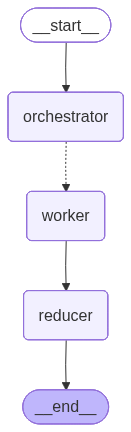

In [21]:
graph = StateGraph(BlogState)

graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer)

graph.add_edge(START,'orchestrator')
graph.add_conditional_edges('orchestrator',fanout,['worker'])
graph.add_edge('worker','reducer')
graph.add_edge('reducer',END)

blog = graph.compile()

blog

In [22]:
response = blog.invoke({'topic':'Attention is all you need'})

print(response)

RAW TITLE: "Demystifying Attention in Neural Networks: A Deep Dive into 'Attention is All You Need'"
FILENAME: 'demystifying_attention_mechanism_in_neural_networks.md'
{'topic': 'Attention is all you need', 'plan': Plan(blog_title="Demystifying Attention in Neural Networks: A Deep Dive into 'Attention is All You Need'", audience='Machine Learning Engineers and Researchers', tone='Technical and Informative', task=[Task(id=1, title='Introduction to Attention Mechanism', goal='Understand the concept of attention in neural networks', bullets=['Explain the need for attention mechanisms in neural networks', 'Introduce the key components of attention mechanisms', 'Discuss the benefits of using attention mechanisms over traditional methods'], target_words=300, section_type='intro'), Task(id=2, title='The Problem with Sequence Modeling', goal='Identify the limitations of traditional sequence modeling approaches', bullets=['Highlight challenges faced by traditional sequence models', 'Explain the

In [23]:
print(response['topic'])
print('*'*100)
print(response['plan'])
print('*'*100)
print(response['plan'].task[0])
print(response['plan'].task[1])
print(response['plan'].task[2])
print(response['plan'].task[3])
print(response['plan'].task[4])
print(response['plan'].task[5])
print('*'*100)
print(response['section'])
print('*'*100)
#print(response['final'])

Attention is all you need
****************************************************************************************************
blog_title="Demystifying Attention in Neural Networks: A Deep Dive into 'Attention is All You Need'" audience='Machine Learning Engineers and Researchers' tone='Technical and Informative' task=[Task(id=1, title='Introduction to Attention Mechanism', goal='Understand the concept of attention in neural networks', bullets=['Explain the need for attention mechanisms in neural networks', 'Introduce the key components of attention mechanisms', 'Discuss the benefits of using attention mechanisms over traditional methods'], target_words=300, section_type='intro'), Task(id=2, title='The Problem with Sequence Modeling', goal='Identify the limitations of traditional sequence modeling approaches', bullets=['Highlight challenges faced by traditional sequence models', 'Explain the issues related to long-range dependencies', 'Compare the performance of traditional models with